# Linear Regression and Gradient Descent for Security Analytics

**Goal:** understand the algorithm—not just call a library. We will predict investigation time from synthetic alert properties, derive the loss and gradients, implement gradient descent, and compare with scikit-learn.

> Defensive, synthetic, local data only. A prediction supports an analyst; it does not replace incident triage.

## 1. Model and learning rule

For one feature, $\hat y = wx+b$. For $n$ examples, mean squared error is

$$J(w,b)=\frac{1}{n}\sum_{i=1}^{n}(wx_i+b-y_i)^2.$$

The gradients are $\partial J/\partial w=\frac{2}{n}\sum x_i(\hat y_i-y_i)$ and $\partial J/\partial b=\frac{2}{n}\sum(\hat y_i-y_i)$. Gradient descent repeatedly applies $w\leftarrow w-\alpha\partial J/\partial w$ and $b\leftarrow b-\alpha\partial J/\partial b$.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 207
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Build a synthetic security dataset

The target is analyst investigation time in minutes. Features available when an alert arrives are safe candidates; post-investigation fields would leak the answer.

In [2]:
n = 500
events = rng.poisson(90, n) + 5
hosts = rng.integers(1, 25, n)
severity = rng.choice(['low', 'medium', 'high'], n, p=[0.45, 0.38, 0.17])
severity_minutes = pd.Series(severity).map({'low': 0, 'medium': 18, 'high': 42}).to_numpy()
noise = rng.normal(0, 10, n)
minutes = 8 + 0.16 * events + 1.7 * hosts + severity_minutes + noise
alerts = pd.DataFrame({
    'event_count': events,
    'affected_hosts': hosts,
    'severity': severity,
    'investigation_minutes': np.maximum(minutes, 5),
})
alerts.head()

,event_count,affected_hosts,severity,investigation_minutes
0,88,2,low,27.843004
1,108,22,low,62.959150
2,105,14,low,32.549927
3,106,16,medium,53.849790
4,95,14,low,38.792946


## 3. Gradient descent from scratch (one feature)

Standardizing $x$ improves the geometry of the loss surface and makes one learning rate practical. The scaler is fit on training data only.

In [3]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    alerts[['event_count']], alerts['investigation_minutes'], test_size=0.25, random_state=RANDOM_STATE
)
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train_1).ravel()
x_test = scaler.transform(X_test_1).ravel()
y_train = y_train_1.to_numpy()

def gradient_descent(x, y, learning_rate=0.08, steps=250):
    w, b = 0.0, 0.0
    history = []
    for _ in range(steps):
        prediction = w * x + b
        error = prediction - y
        loss = np.mean(error ** 2)
        dw = 2 * np.mean(x * error)
        db = 2 * np.mean(error)
        w -= learning_rate * dw
        b -= learning_rate * db
        history.append(loss)
    return w, b, np.array(history)

w, b, history = gradient_descent(x_train, y_train)
gd_prediction = w * x_test + b
print(f'w={w:.3f}, b={b:.3f}')
print(f'Test MAE: {mean_absolute_error(y_test_1, gd_prediction):.2f} minutes')

w=1.393, b=58.349
Test MAE: 17.81 minutes


### Teaching visual: watch the model learn

The pictures below show the same optimization in two coordinate systems:

1. **Data space:** each gradient step changes the slope $w$ and intercept $b$, moving the fitted line closer to the observations.
2. **Parameter space:** every point represents one candidate $(w,b)$ pair. Contours are equal-loss regions, and the optimization path moves downhill toward the minimum.

Use the early snapshots to emphasize that gradient descent updates **parameters**, not individual predictions. The arrows on the contour plot show both update direction and update size.

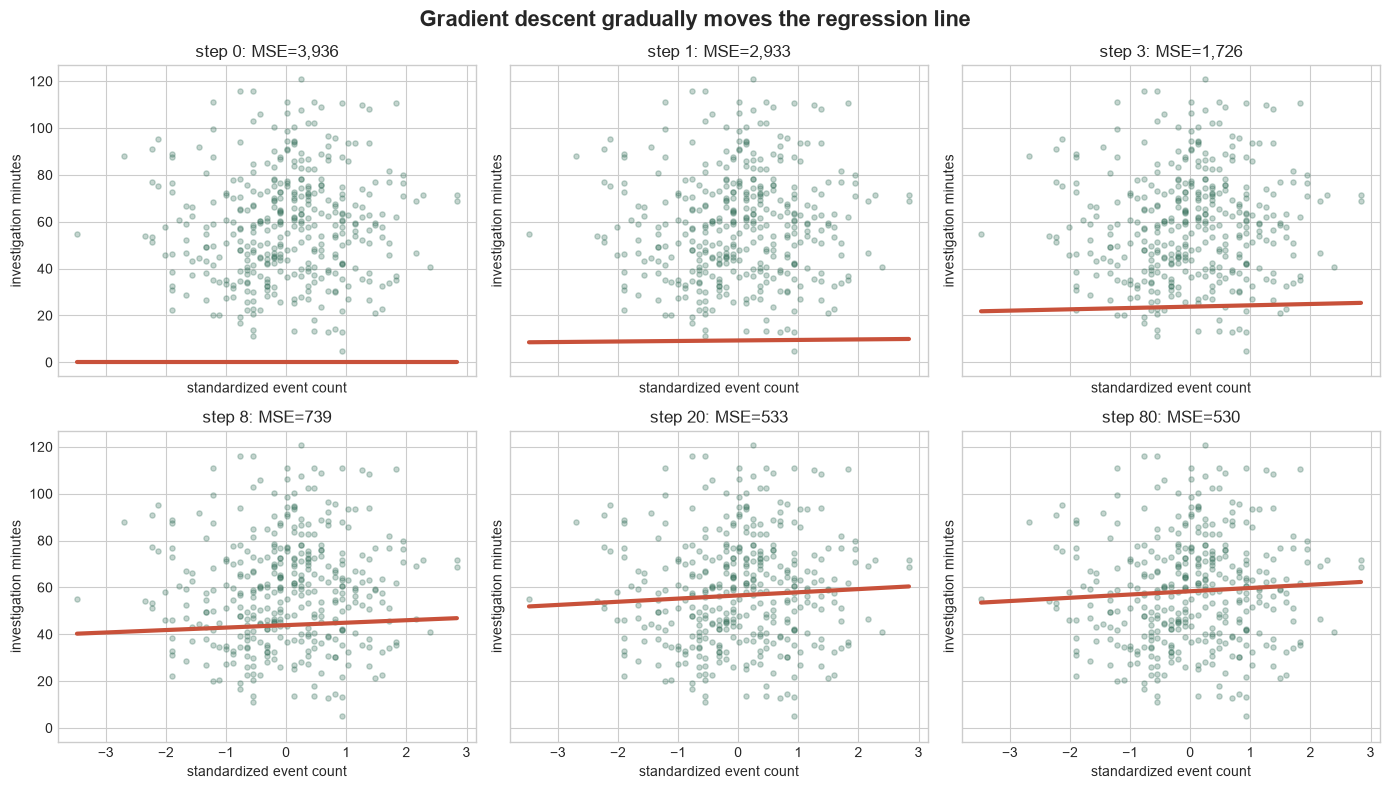

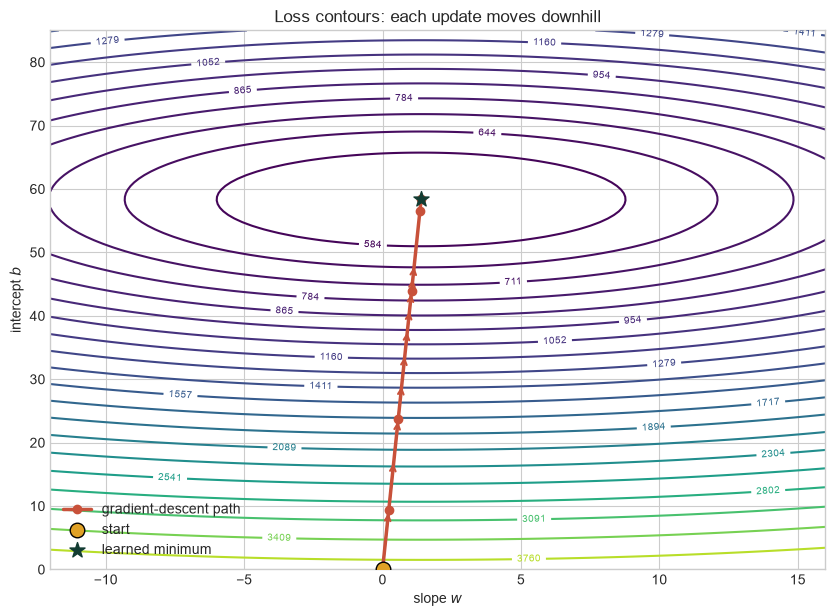

In [11]:
def gradient_descent_states(x, y, learning_rate=0.08, steps=80):
    """Return parameters and loss before every update, plus the final state."""
    w_state, b_state = 0.0, 0.0
    states = []
    for step in range(steps):
        prediction_state = w_state * x + b_state
        error_state = prediction_state - y
        loss_state = np.mean(error_state ** 2)
        states.append((step, w_state, b_state, loss_state))
        dw_state = 2 * np.mean(x * error_state)
        db_state = 2 * np.mean(error_state)
        w_state -= learning_rate * dw_state
        b_state -= learning_rate * db_state
    final_error = w_state * x + b_state - y
    states.append((steps, w_state, b_state, np.mean(final_error ** 2)))
    return np.asarray(states)

# Use explicit NumPy arrays so this cell remains correct after later cells reuse y_train.
y_visual = y_train_1.to_numpy()
teaching_states = gradient_descent_states(x_train, y_visual)
snapshot_steps = [0, 1, 3, 8, 20, 80]
x_line = np.linspace(x_train.min(), x_train.max(), 150)

# Visual 1: how the fitted line changes over selected iterations.
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, step in zip(axes.ravel(), snapshot_steps):
    _, w_step, b_step, loss_step = teaching_states[step]
    ax.scatter(x_train, y_visual, s=14, alpha=0.28, color='#2f6b55')
    ax.plot(x_line, w_step * x_line + b_step, color='#c8513a', linewidth=3)
    ax.set_title(f'step {step}: MSE={loss_step:,.0f}')
    ax.set_xlabel('standardized event count')
    ax.set_ylabel('investigation minutes')
fig.suptitle('Gradient descent gradually moves the regression line', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Visual 2: the same updates on the loss surface in parameter space.
w_values = np.linspace(-12, 16, 150)
b_values = np.linspace(0, 85, 150)
W, B = np.meshgrid(w_values, b_values)
loss_surface = np.mean(
    (W[..., None] * x_train[None, None, :] + B[..., None] - y_visual[None, None, :]) ** 2,
    axis=2,
)

fig, ax = plt.subplots(figsize=(10, 7))
levels = np.geomspace(max(loss_surface.min(), 1), loss_surface.max(), 22)
contours = ax.contour(W, B, loss_surface, levels=levels, cmap='viridis')
ax.clabel(contours, inline=True, fontsize=7, fmt='%.0f')
path = teaching_states[:, 1:3]
ax.plot(path[:, 0], path[:, 1], color='#c8513a', linewidth=2.5, marker='o',
        markevery=[0, 1, 3, 8, 20, 80], label='gradient-descent path')
for start, end in zip(path[:10], path[1:11]):
    ax.annotate('', xy=end, xytext=start,
                arrowprops={'arrowstyle': '->', 'color': '#c8513a', 'lw': 1.5})
ax.scatter(path[0, 0], path[0, 1], s=110, color='#e0a126', edgecolor='black', zorder=5, label='start')
ax.scatter(path[-1, 0], path[-1, 1], s=130, color='#123c32', marker='*', zorder=5, label='learned minimum')
ax.set(xlabel='slope $w$', ylabel='intercept $b$', title='Loss contours: each update moves downhill')
ax.legend()
plt.show()

#### Instructor prompts for the visuals

- **Step 0:** Why is the line at zero? Which parameter choices produced it?
- **Early steps:** Why does the intercept move much more than the slope here?
- **Contour path:** Why are the first arrows long and later arrows short even though the learning rate is constant?
- **At the minimum:** Does a near-zero gradient imply zero prediction error? Why not?
- **Security connection:** If incident severity is omitted, what pattern would you expect in the residuals?

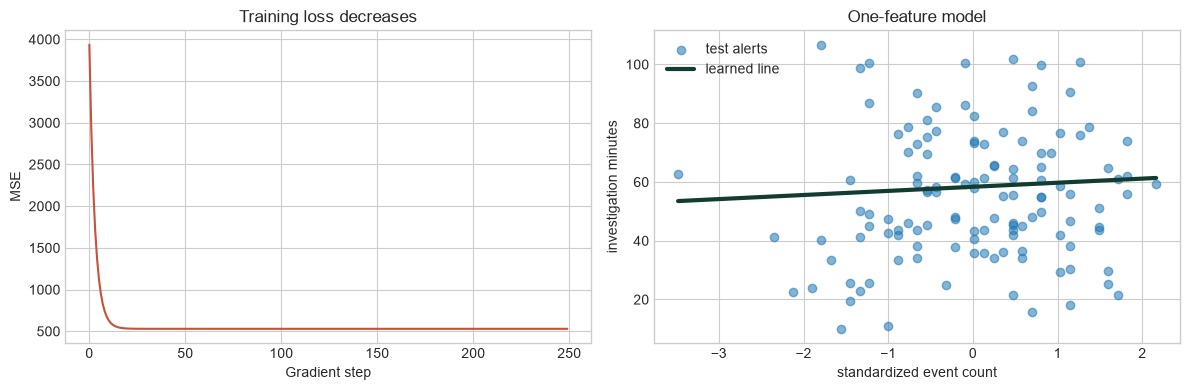

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history, color='#c8513a')
axes[0].set(title='Training loss decreases', xlabel='Gradient step', ylabel='MSE')
order = np.argsort(x_test)
axes[1].scatter(x_test, y_test_1, alpha=0.55, label='test alerts')
axes[1].plot(x_test[order], gd_prediction[order], color='#123c32', linewidth=3, label='learned line')
axes[1].set(title='One-feature model', xlabel='standardized event count', ylabel='investigation minutes')
axes[1].legend();
plt.tight_layout()

### Learning-rate experiment
A tiny rate learns slowly; an appropriate rate converges; an excessive rate can oscillate or diverge.

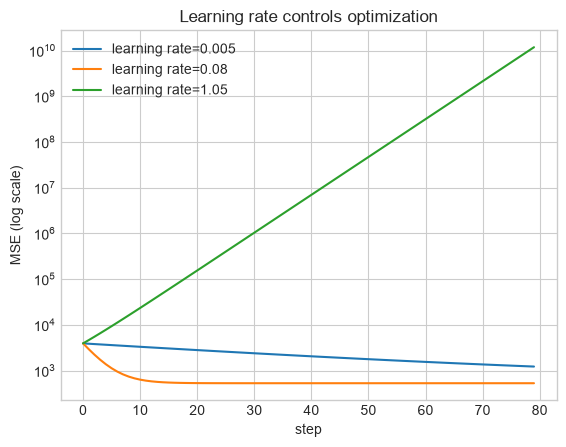

In [6]:
for rate in [0.005, 0.08, 1.05]:
    _, _, losses = gradient_descent(x_train, y_train, learning_rate=rate, steps=80)
    plt.plot(losses, label=f'learning rate={rate}')
plt.yscale('log')
plt.xlabel('step'); plt.ylabel('MSE (log scale)'); plt.title('Learning rate controls optimization'); plt.legend();

## 4. Multiple regression with a leakage-safe pipeline

The pipeline learns scaling and category encoding only from the training partition. We compare against the training median because a model must beat a simple operational baseline.

In [7]:
X = alerts.drop(columns='investigation_minutes')
y = alerts['investigation_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)
preprocess = ColumnTransformer([
    ('numbers', StandardScaler(), ['event_count', 'affected_hosts']),
    ('severity', OneHotEncoder(handle_unknown='ignore'), ['severity']),
])
model = Pipeline([('preprocess', preprocess), ('regressor', Ridge(alpha=1.0))])
model.fit(X_train, y_train)
prediction = model.predict(X_test)
baseline = np.full(len(y_test), y_train.median())
results = pd.DataFrame({
    'model': ['training-median baseline', 'ridge regression'],
    'MAE_minutes': [mean_absolute_error(y_test, baseline), mean_absolute_error(y_test, prediction)],
    'RMSE_minutes': [mean_squared_error(y_test, baseline) ** 0.5, mean_squared_error(y_test, prediction) ** 0.5],
    'R2': [r2_score(y_test, baseline), r2_score(y_test, prediction)],
})
results.round(3)

,model,MAE_minutes,RMSE_minutes,R2
0,training-median baseline,17.836,21.90,-0.019
1,ridge regression,9.224,11.64,0.712


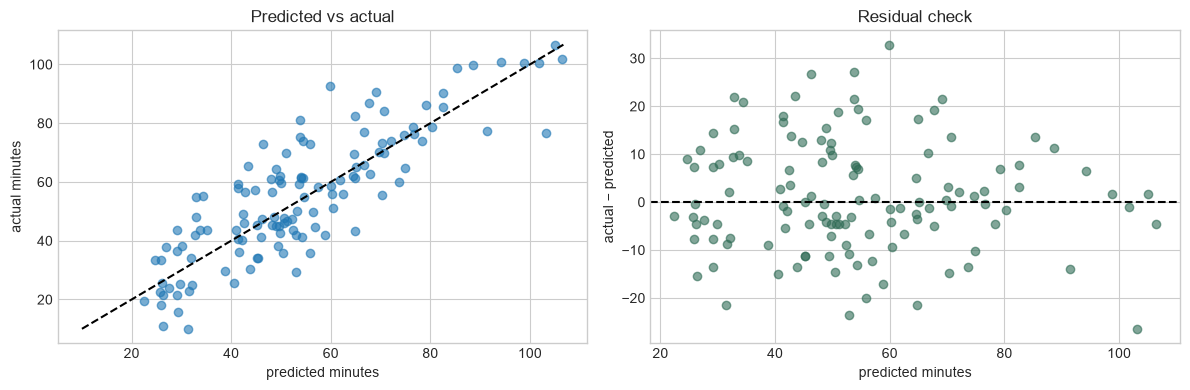

In [8]:
residual = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(prediction, y_test, alpha=0.6)
limits = [min(prediction.min(), y_test.min()), max(prediction.max(), y_test.max())]
axes[0].plot(limits, limits, '--', color='black')
axes[0].set(title='Predicted vs actual', xlabel='predicted minutes', ylabel='actual minutes')
axes[1].scatter(prediction, residual, alpha=0.6, color='#2f6b55')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set(title='Residual check', xlabel='predicted minutes', ylabel='actual − predicted')
plt.tight_layout()

## 5. Security interpretation and exercises

**What the algorithm assumes:** additive effects, a roughly linear conditional mean, and training data representative of deployment. Correlation is not causation. Large residuals may identify unusual incidents worth review, but are not proof of maliciousness.

**Try:**
1. Change the learning rate and explain the loss curve.
2. Add an interaction such as `event_count * affected_hosts`; evaluate on the unchanged test set.
3. Report MAE separately by severity and discuss who bears underestimation cost.
4. Name one tempting post-investigation field that would cause leakage.